In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
df=pd.read_csv("mental_health.csv")
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0


In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Person_ID                 2000 non-null   int64  
 1   Age                       2000 non-null   int64  
 2   Gender                    2000 non-null   object 
 3   Occupation                2000 non-null   object 
 4   Daily_Screen_Time         2000 non-null   float64
 5   Social_Media_Usage        2000 non-null   float64
 6   Night_Usage               2000 non-null   int64  
 7   Sleep_Hours               2000 non-null   float64
 8   Stress_Level              2000 non-null   int64  
 9   Work_Study_Hours          2000 non-null   float64
 10  Physical_Activity         2000 non-null   object 
 11  Social_Interaction_Score  2000 non-null   int64  
 12  Caffeine_Intake           2000 non-null   int64  
 13  Smoking                   2000 non-null   int64  
 14  Alcohol 

In [96]:
df[["Age","Daily_Screen_Time","Sleep_Hours"]].describe()

,Age,Daily_Screen_Time,Sleep_Hours
count,2000.000000,2000.000000,2000.00000
mean,37.694000,6.943150,6.00765
std,12.614195,2.882415,1.70631
min,16.000000,2.000000,3.00000
25%,27.000000,4.500000,4.60000
50%,38.000000,6.800000,6.00000
75%,49.000000,9.400000,7.50000
max,59.000000,12.000000,9.00000


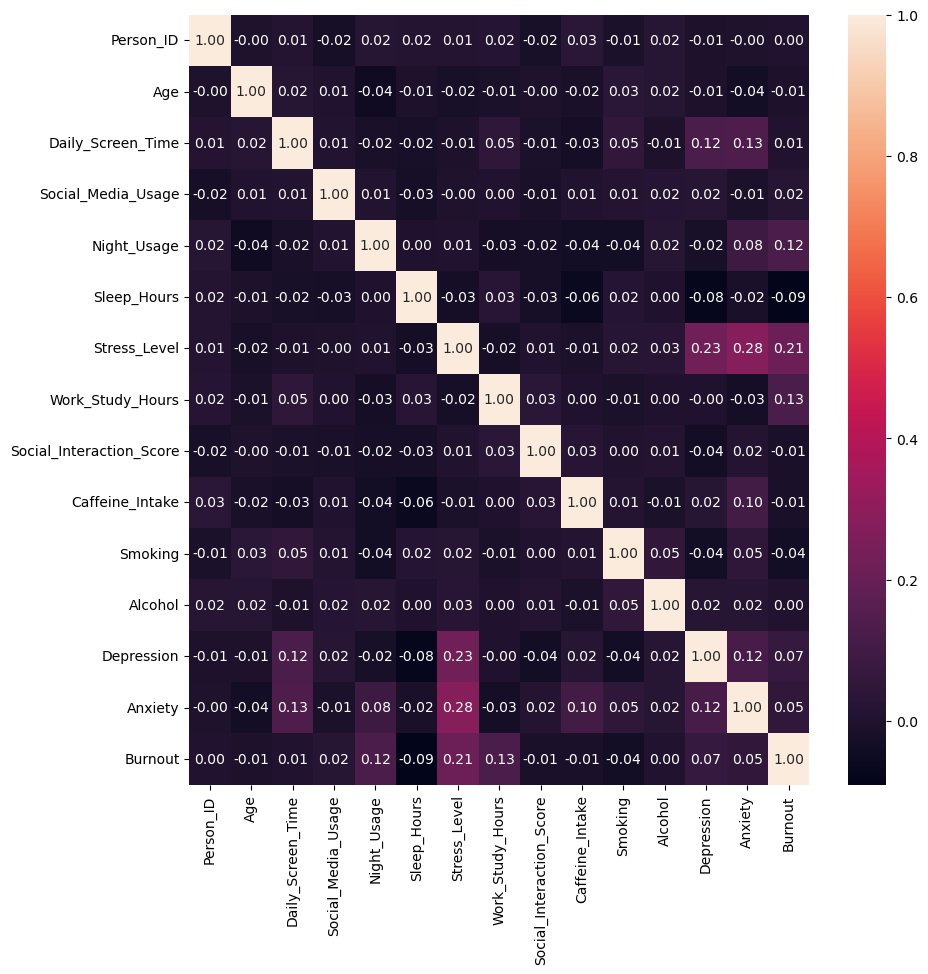

In [97]:
plt.figure(figsize=(10,10))
sns.heatmap(df.select_dtypes(include=["int64","float64"]).corr(),annot=True,fmt=".2f")
plt.show()

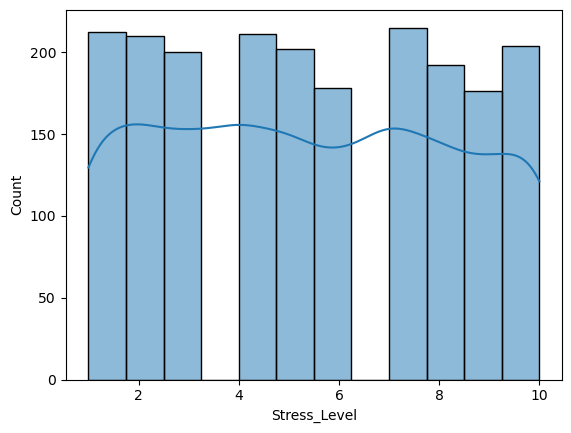

In [98]:
sns.histplot(df["Stress_Level"],kde=True)
plt.show()

In [99]:
df["Age Group"]=pd.cut(df["Age"],[0,15,30,45,60,75,90,105])
df.head()
print(df.groupby("Age Group",observed=True)["Stress_Level"].mean())

Age Group
(15, 30]    5.502994
(30, 45]    5.367883
(45, 60]    5.357032
Name: Stress_Level, dtype: float64


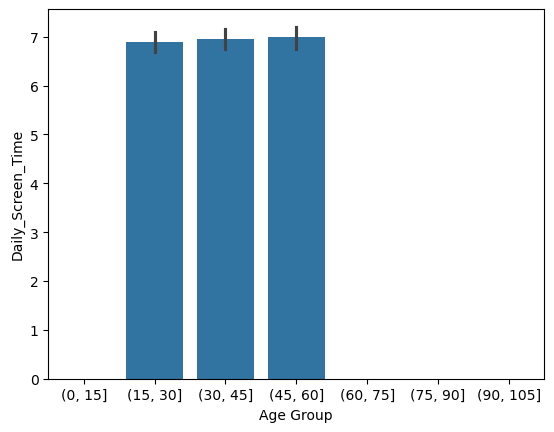

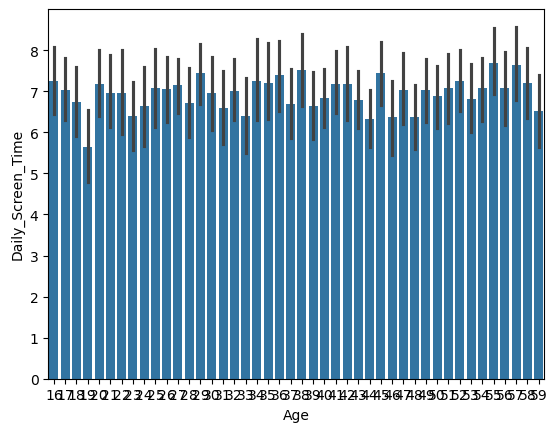

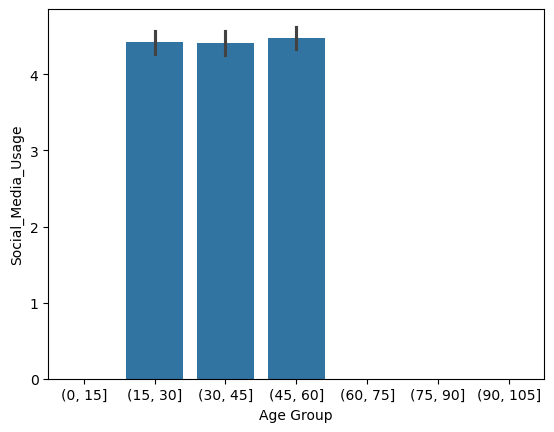

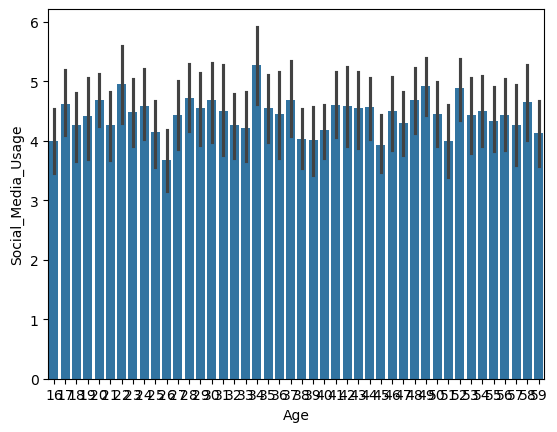

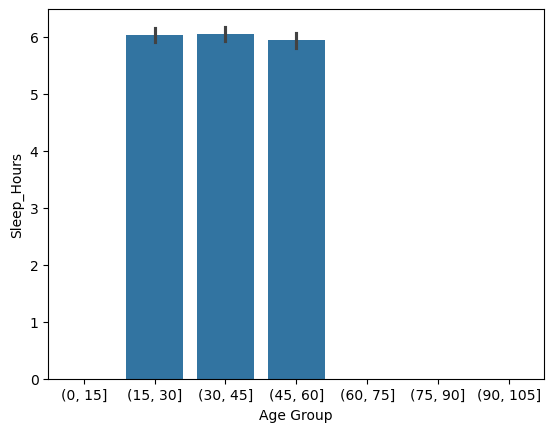

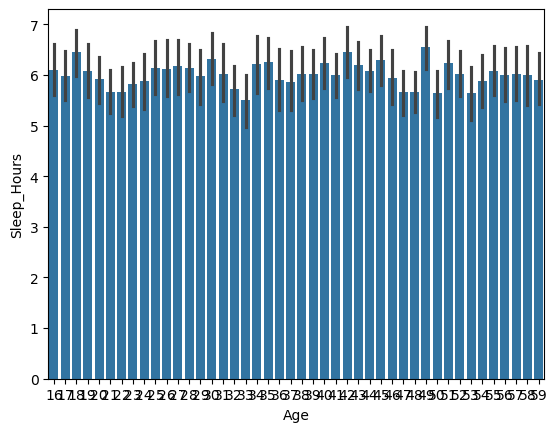

In [100]:
istenen=["Daily_Screen_Time","Social_Media_Usage","Sleep_Hours"]
for i in istenen:
    sns.barplot(x="Age Group",y=i,data=df)
    plt.show()
    sns.barplot(x="Age",y=i,data=df)
    plt.show()


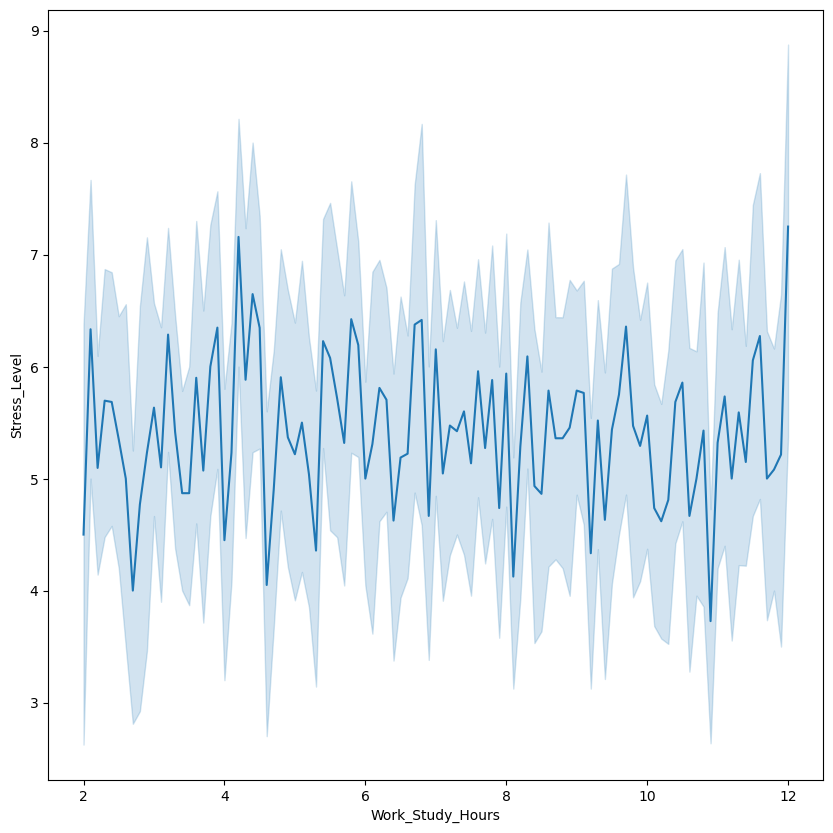

                  Work_Study_Hours  Stress_Level
Work_Study_Hours          1.000000     -0.022692
Stress_Level             -0.022692      1.000000


In [101]:
plt.figure(figsize=(10,10))
sns.lineplot(x=df["Work_Study_Hours"],y=df['Stress_Level'],data=df)
plt.show()
print(df[["Work_Study_Hours",'Stress_Level']].corr())

                   Stress_Level  Daily_Screen_Time
Stress_Level           1.000000          -0.007215
Daily_Screen_Time     -0.007215           1.000000


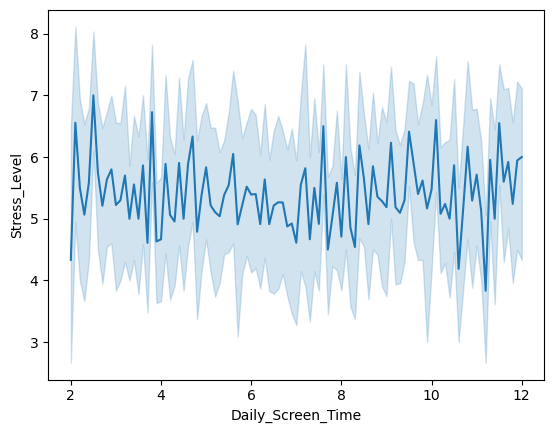

                    Stress_Level  Social_Media_Usage
Stress_Level            1.000000           -0.003526
Social_Media_Usage     -0.003526            1.000000


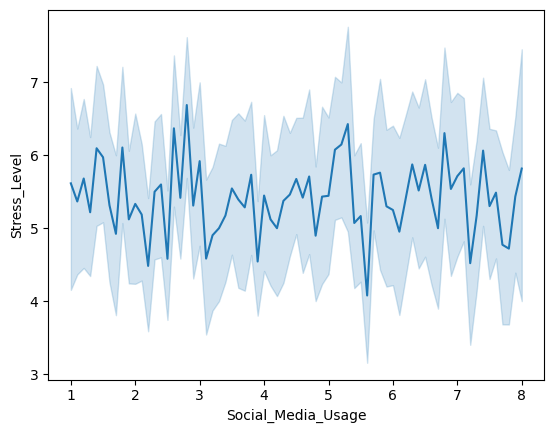

              Stress_Level  Sleep_Hours
Stress_Level      1.000000    -0.028459
Sleep_Hours      -0.028459     1.000000


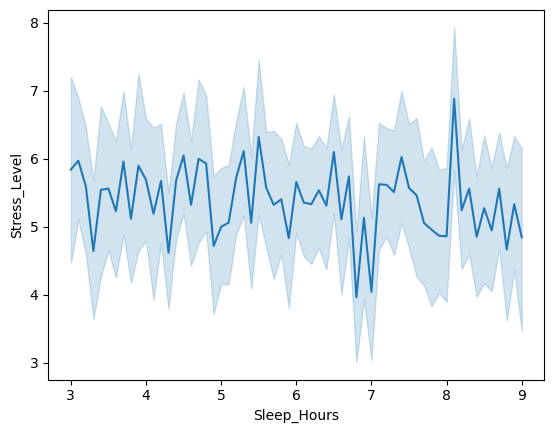

In [102]:

for i in istenen:
    sns.lineplot(x=i,y="Stress_Level",data=df)
    print(df[["Stress_Level",i]].corr())
    plt.show()

In [103]:
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout,Age Group
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1,"(45, 60]"
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0,"(30, 45]"
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1,"(15, 30]"
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0,"(45, 60]"
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0,"(15, 30]"


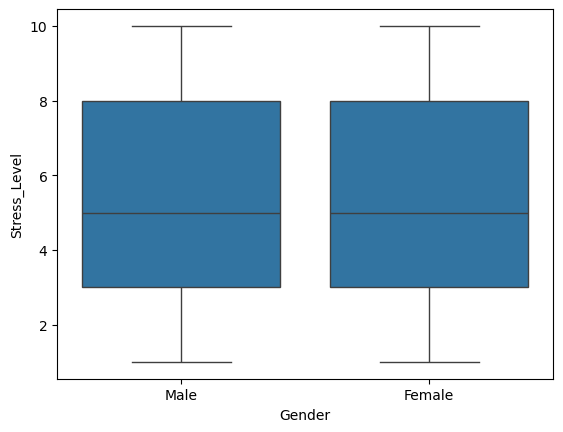

In [104]:
sns.boxplot(x="Gender",y="Stress_Level",data=df)
plt.show()

In [105]:
df["Physical_Activity"].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [106]:
df["pyhsical_activity_nums"]=df["Physical_Activity"].map({
    "Low":0,
    "Medium":1,
    "High":2      
})
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout,Age Group,pyhsical_activity_nums
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1,"(45, 60]",0
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0,"(30, 45]",2
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1,"(15, 30]",0
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0,"(45, 60]",2
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0,"(15, 30]",0


In [107]:
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout,Age Group,pyhsical_activity_nums
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1,"(45, 60]",0
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0,"(30, 45]",2
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1,"(15, 30]",0
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0,"(45, 60]",2
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0,"(15, 30]",0


In [108]:
print(df[["Stress_Level","pyhsical_activity_nums"]].corr())

                        Stress_Level  pyhsical_activity_nums
Stress_Level                1.000000               -0.009613
pyhsical_activity_nums     -0.009613                1.000000


In [109]:
#Fiziksel aktivite ile stres seviyesi arasında belirgin bir lineer ilişki gözlemlenmemiştir.
#Günlük ekran süresi ile stres seviyesi arasında belirgin bir lineer ilişki gözlemlenmemiştir.
#günlük sosyal ile stres seviyesi arasında belirgin bir lineer ilişki gözlemlenmemiştir.
#Günlük uyku süresi ile stres seviyesi arasında belirgin bir lineer ilişki gözlemlenmemiştir.

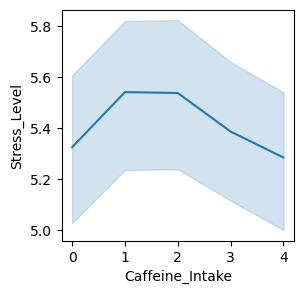

                        Caffeine_Intake  Stress_Level
Gender                                               
Female Caffeine_Intake         1.000000     -0.010228
       Stress_Level           -0.010228      1.000000
Male   Caffeine_Intake         1.000000     -0.011567
       Stress_Level           -0.011567      1.000000


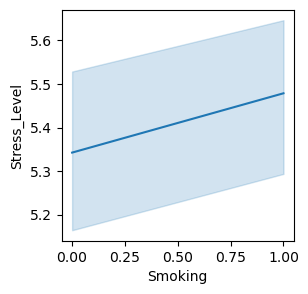

                      Smoking  Stress_Level
Gender                                     
Female Smoking       1.000000     -0.007655
       Stress_Level -0.007655      1.000000
Male   Smoking       1.000000      0.053824
       Stress_Level  0.053824      1.000000


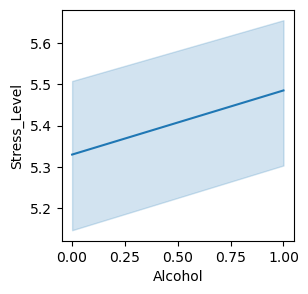

                      Alcohol  Stress_Level
Gender                                     
Female Alcohol       1.000000      0.047154
       Stress_Level  0.047154      1.000000
Male   Alcohol       1.000000      0.006556
       Stress_Level  0.006556      1.000000


In [117]:
dis_etken=["Caffeine_Intake","Smoking","Alcohol"]
for i in dis_etken:
    plt.figure(figsize=(3,3))
    sns.lineplot(x=i,y="Stress_Level",data=df,markers=True)
    plt.show()
    print(df.groupby("Gender")[[i,"Stress_Level"]].corr())

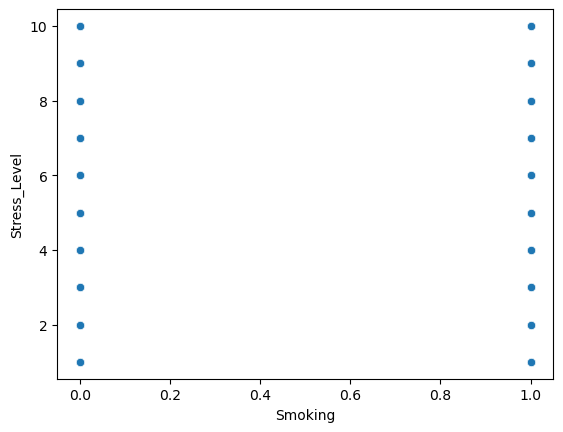

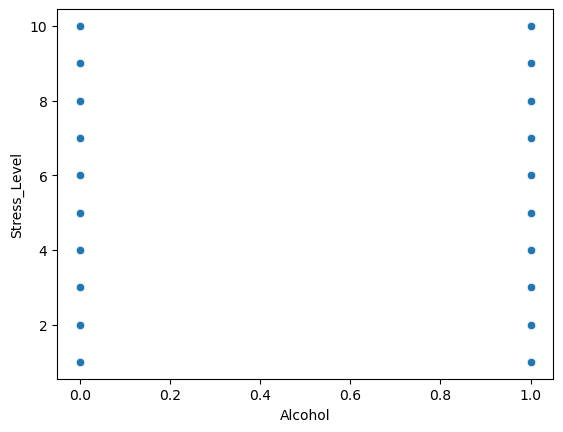

In [118]:
sns.scatterplot(x="Smoking",y="Stress_Level",data=df)
plt.show()
sns.scatterplot(x="Alcohol",y="Stress_Level",data=df)
plt.show()

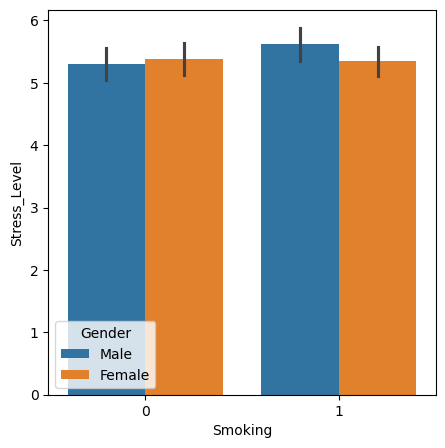

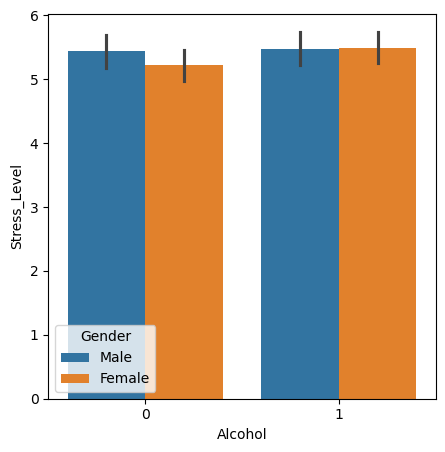

In [119]:
plt.figure(figsize=(5,5))
sns.barplot(x="Smoking",y="Stress_Level",data=df,hue="Gender")
plt.show()
plt.figure(figsize=(5,5))
sns.barplot(x="Alcohol",y="Stress_Level",data=df,hue="Gender")
plt.show()

In [120]:
#Alkol ve sigara kullanımının stres seviyesi üzerinde net bir etkisi yoktur
#Kafein kullanımı ise belirli değerlerde arttırsada anlamlı bir etkisi yoktur

In [121]:
df.head()

,Person_ID,Age,Gender,Occupation,Daily_Screen_Time,Social_Media_Usage,Night_Usage,Sleep_Hours,Stress_Level,Work_Study_Hours,Physical_Activity,Social_Interaction_Score,Caffeine_Intake,Smoking,Alcohol,Depression,Anxiety,Burnout,Age Group,pyhsical_activity_nums
0,1,54,Male,Student,10.2,7.5,0,6.5,8,5.8,Low,6,2,0,1,1,1,1,"(45, 60]",0
1,2,44,Male,Student,6.8,4.5,0,5.1,4,7.9,High,2,1,1,0,0,0,0,"(30, 45]",2
2,3,30,Male,Employed,5.5,6.9,0,3.5,10,9.4,Low,2,0,1,1,1,0,1,"(15, 30]",0
3,4,58,Male,Employed,5.6,4.1,0,9.0,2,2.0,High,10,0,0,1,0,0,0,"(45, 60]",2
4,5,23,Female,Employed,10.1,6.0,1,3.8,4,4.6,Low,4,4,0,1,1,1,0,"(15, 30]",0


                     Depression  Stress_Level
Gender                                       
Female Depression      1.000000      0.237237
       Stress_Level    0.237237      1.000000
Male   Depression      1.000000      0.213878
       Stress_Level    0.213878      1.000000


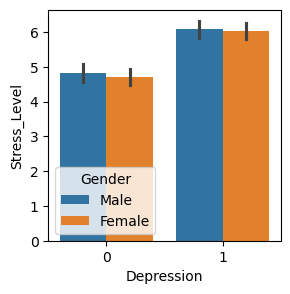

                      Anxiety  Stress_Level
Gender                                     
Female Anxiety       1.000000      0.301909
       Stress_Level  0.301909      1.000000
Male   Anxiety       1.000000      0.255820
       Stress_Level  0.255820      1.000000


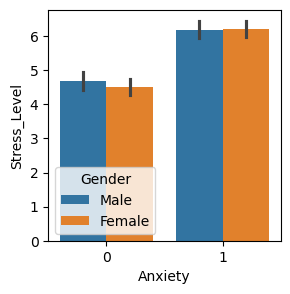

                      Burnout  Stress_Level
Gender                                     
Female Burnout       1.000000      0.219692
       Stress_Level  0.219692      1.000000
Male   Burnout       1.000000      0.197115
       Stress_Level  0.197115      1.000000


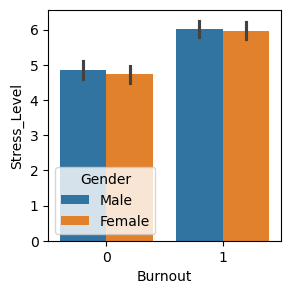

In [122]:
psikolojik_etkenler=["Depression","Anxiety","Burnout"]
for i in psikolojik_etkenler:
    print(df.groupby("Gender")[[i,"Stress_Level"]].corr())
    plt.figure(figsize=(3,3))
    sns.barplot(x=i,y="Stress_Level",data=df,hue="Gender")
    plt.show()
    

In [123]:
#kadınların erkeklere göre psikolojik etkenlere daha duyarlı fakat bu çok fazla değil.
#Verilere baktığımızda depresyon,anksiyete ve tükenmişlik hissi stres seviyesini doğru orantılıdır. 